Cole (2025), "Are there too many traits in our selection indices?"
=
This notebook calculates expected genetic response using the method of VanRaden et al. (2025). Data came from the following sources:
* Genotyped US Holstein cows born in 2023
* August 2025 genetic evaluation run
* Correlations of individual traits with each selection index and SD(PTA) computed using /home/jcole/python/toomanytraits/sas/checkPTA.sas on the CDCB development server

In [204]:
import numpy as np
import pandas as pd
import seaborn as sns

We need to make our dataframe look like this:

In [205]:
excel_data = [
    ('Milk', 162.7941326, 126.329841, 100.4262458, 110.7876839, 109.7913918, 71.73303275, 62.16862838, 80.10188657, 72.72932487, 69.7404485, 80.50040342, 79.50411129),
    ('Fat', 7.536168962, 8.566836988, 9.086898836, 8.14133184, 7.715826691, 7.517257622, 7.167397833, 8.0278638, 8.08459782, 8.264255549, 7.800927721, 7.923851431),
    ('Protein', 4.648028795, 4.789993475, 4.421936896, 4.474516407, 4.453484603, 3.712113494, 3.417668231, 3.964495148,	3.796240712, 3.759435054, 3.822530468, 3.69108169),
    ('PL', 0.105735769, 0.13519449,	0.140454976, 0.300899799, 0.313524966, 0.378754992, 0.403479276, 0.342457639, 0.349822319, 0.338775298, 0.357713048, 0.346139979),
    ('SCS', 0.00350622, 0.000876555, -0.000645883, -0.010749334, -0.012825385, -0.017115892, -0.018961271, -0.013978747, -0.01379421, -0.012686982, -0.012410175, -0.011395217),
    ('BSC/BWC', -0.062752553, -0.05343558, -0.052613494, -0.069055211, -0.068781182, -0.073713697, -0.082482613, -0.076179955, -0.085222899, -0.081934556, -0.111529646, -0.123860934),
    ('UDC', 0.023666502, 0.027685342, 0.02813188, 0.032820526, 0.06206875, 0.056933566, 0.05604049, 0.05604049, 0.047333004, 0.046439928, 0.028578417, 0.017638242),
    ('FLC', -0.021125164, -0.013278675, -0.00985841, -0.014687019, 0.003822649, 0.003822649, 0.003420265, 0.00100596, -0.004023841, -0.003219073, -0.019515628, -0.025752581),
    ('DPR', -0.216469061, -0.189120721, -0.174751255, -0.093633298, -0.088070924, 0.024567153, 0.056087273, -0.02364009, -0.015296529, -0.01946831, -0.01946831, -0.031056589),
    ('CT$', 0.833709651, 1.016719086, 1.065521602, 1.427473597, 1.374604205, 1.850428737, 1.8910975, 1.756890581, 1.826027479, 1.809759974, 1.8910975, 1.887030624),
    ('HCR', 0.004300288, 0.011467436, 0.018156773, 0.067371184, 0.072627092, 0.124708362, 0.139042656, 0.112285307, 0.113718736, 0.111807497, 0.117063405, 0.113718736),
    ('CCR', -0.140245541, -0.10672071, -0.093310778, 0.016762415, 0.021232393, 0.144715518, 0.179357843, 0.094428273, 0.102250733, 0.096104514, 0.101691986, 0.089399548),
    ('LIV', -0.098633478, -0.061645924, -0.04006985, 0.093085344, 0.080139701, 0.175690882, 0.208363221, 0.136237491, 0.183704852, 0.17754026, 0.197883414, 0.205280925),
    ('GL', -0.072870323, -0.079701915, -0.074767987, -0.078942849, -0.072111257, -0.071352191, -0.068315927, -0.073629388, -0.076665652, -0.076286119, -0.083117712, -0.083117712),
    ('HTH$', 0.106447781, 0.345955287, 0.431113511, 0.971335998, 1.008592721, 1.31463009, 1.402449509, 1.165603198, 1.200198726, 1.216165893, 1.216165893, 1.157619614),
    ('RFI', -0.227375573, -0.056843893, 0.227375573, -1.676894849, -1.819004582, -2.160067941, -2.415865461, -1.932692368, -2.046380155, -1.875848475, -5.570701533, -5.854920999),
    ('MFEV', 0.001343663, 0.002127466, 0.002724649, 0.00432958, 0.004030988, 0.005150707, 0.005449299, 0.004814791, 0.005374651, 0.005635919, 0.005113383, 0.005150707),
    ('DSAB', 0.0110754, 0.015367118, 0.016751543, 0.033641528, 0.032810873, 0.039456113, 0.041671193, 0.036410378, 0.0387639, 0.040009883, 0.042501848, 0.041948078),
    ('KETO', -0.004442343, 0.011599451, 0.010859061, 0.043929836, 0.048618976, 0.05997163, 0.062686395, 0.051580537, 0.051580537, 0.052074131, 0.051333741, 0.044176633),
    ('MAST', -0.073147623, -0.028860967, -0.007961646, 0.087080503, 0.104994207, 0.161223332, 0.181127447, 0.12987435, 0.131367159, 0.127386336, 0.119922293, 0.107979824),
    ('METR', 0.062539527, 0.078301522, 0.081860682, 0.107029028, 0.104486771, 0.122536797, 0.125079054, 0.116689605, 0.119740314, 0.122791023, 0.1235537, 0.121265668),
    ('REPL', -0.01019214, -0.007258039, -0.005868202, 0.003242954, 0.002470822, 0.009883288, 0.01189083, 0.006022628, 0.007258039, 0.008802303, 0.008339024, 0.007258039),
    ('EFC', 0.273257177, 0.280013536, 0.267251525, 0.30929109, 0.29427696, 0.307789677, 0.304036145, 0.30929109, 0.307038971, 0.304036145, 0.333313699, 0.32880946),
    ('HLIV', 0.004222091, 0.000938242, 0.000312747, 0.014699131, 0.016575616, 0.019546717, 0.021735949, 0.016888363, 0.017670232, 0.016106495, 0.019546717, 0.019546717),
]

In [206]:
wide_response = pd.DataFrame.from_records(excel_data,
                                          columns=['variable', 'PD$ 1971', 'MFP$ 1976',
                                                   'CY$ 1984', 'NM$ 1994', 'NM$ 2000',
                                                   'NM$ 2006', 'NM$ 2010', 'NM$ 2014',
                                                   'NM$ 2017', 'NM$ 2018', 'NM$ 2021',
                                                   'NM$ 2025'])

In [207]:
wide_response.head()

,variable,PD$ 1971,MFP$ 1976,CY$ 1984,NM$ 1994,NM$ 2000,NM$ 2006,NM$ 2010,NM$ 2014,NM$ 2017,NM$ 2018,NM$ 2021,NM$ 2025
0,Milk,162.794133,126.329841,100.426246,110.787684,109.791392,71.733033,62.168628,80.101887,72.729325,69.740448,80.500403,79.504111
1,Fat,7.536169,8.566837,9.086899,8.141332,7.715827,7.517258,7.167398,8.027864,8.084598,8.264256,7.800928,7.923851
2,Protein,4.648029,4.789993,4.421937,4.474516,4.453485,3.712113,3.417668,3.964495,3.796241,3.759435,3.822530,3.691082
3,PL,0.105736,0.135194,0.140455,0.300900,0.313525,0.378755,0.403479,0.342458,0.349822,0.338775,0.357713,0.346140
4,SCS,0.003506,0.000877,-0.000646,-0.010749,-0.012825,-0.017116,-0.018961,-0.013979,-0.013794,-0.012687,-0.012410,-0.011395


In [208]:
tall_response = pd.lreshape(
    wide_response,
    {
        'value': ['PD$ 1971', 'MFP$ 1976', 'CY$ 1984', 'NM$ 1994', 'NM$ 2000',
                   'NM$ 2006', 'NM$ 2010', 'NM$ 2014', 'NM$ 2017', 'NM$ 2018',
                   'NM$ 2021', 'NM$ 2025']
    }
)

indices = ['PD$ 1971', 'MFP$ 1976', 'CY$ 1984', 'NM$ 1994', 'NM$ 2000', 'NM$ 2006',
           'NM$ 2010', 'NM$ 2014', 'NM$ 2017', 'NM$ 2018', 'NM$ 2021', 'NM$ 2025']

years = ['1971', '1976', '1984', '1994', '2000', '2006', '2010', '2014', '2017',
         '2018', '2021', '2025']

In [209]:
indices = ['PD$ 1971', 'MFP$ 1976', 'CY$ 1984', 'NM$ 1994', 'NM$ 2000', 'NM$ 2006',
           'NM$ 2010', 'NM$ 2014', 'NM$ 2017', 'NM$ 2018', 'NM$ 2021', 'NM$ 2025']
name_list = []
for idx in indices:
    name_list.extend([idx]*24)
tall_response['Index Name'] = name_list

In [210]:
years = ['1971', '1976', '1984', '1994', '2000', '2006', '2010', '2014', '2017',
         '2018', '2021', '2025']
year_list = []
for yr in years:
    year_list.extend([yr]*24)
tall_response['Year'] = year_list

In [211]:
tall_response.head(n=24)

,variable,value,Index Name,Year
0,Milk,162.794133,PD$ 1971,1971
1,Fat,7.536169,PD$ 1971,1971
2,Protein,4.648029,PD$ 1971,1971
3,PL,0.105736,PD$ 1971,1971
4,SCS,0.003506,PD$ 1971,1971
5,BSC/BWC,-0.062753,PD$ 1971,1971
6,UDC,0.023667,PD$ 1971,1971
7,FLC,-0.021125,PD$ 1971,1971
8,DPR,-0.216469,PD$ 1971,1971
9,CT$,0.833710,PD$ 1971,1971


In [212]:
tall_response.tail(n=24)

,variable,value,Index Name,Year
264,Milk,79.504111,NM$ 2025,2025
265,Fat,7.923851,NM$ 2025,2025
266,Protein,3.691082,NM$ 2025,2025
267,PL,0.346140,NM$ 2025,2025
268,SCS,-0.011395,NM$ 2025,2025
269,BSC/BWC,-0.123861,NM$ 2025,2025
270,UDC,0.017638,NM$ 2025,2025
271,FLC,-0.025753,NM$ 2025,2025
272,DPR,-0.031057,NM$ 2025,2025
273,CT$,1.887031,NM$ 2025,2025


In [203]:
tall_response.sort_values(by=['Year'], inplace=True)

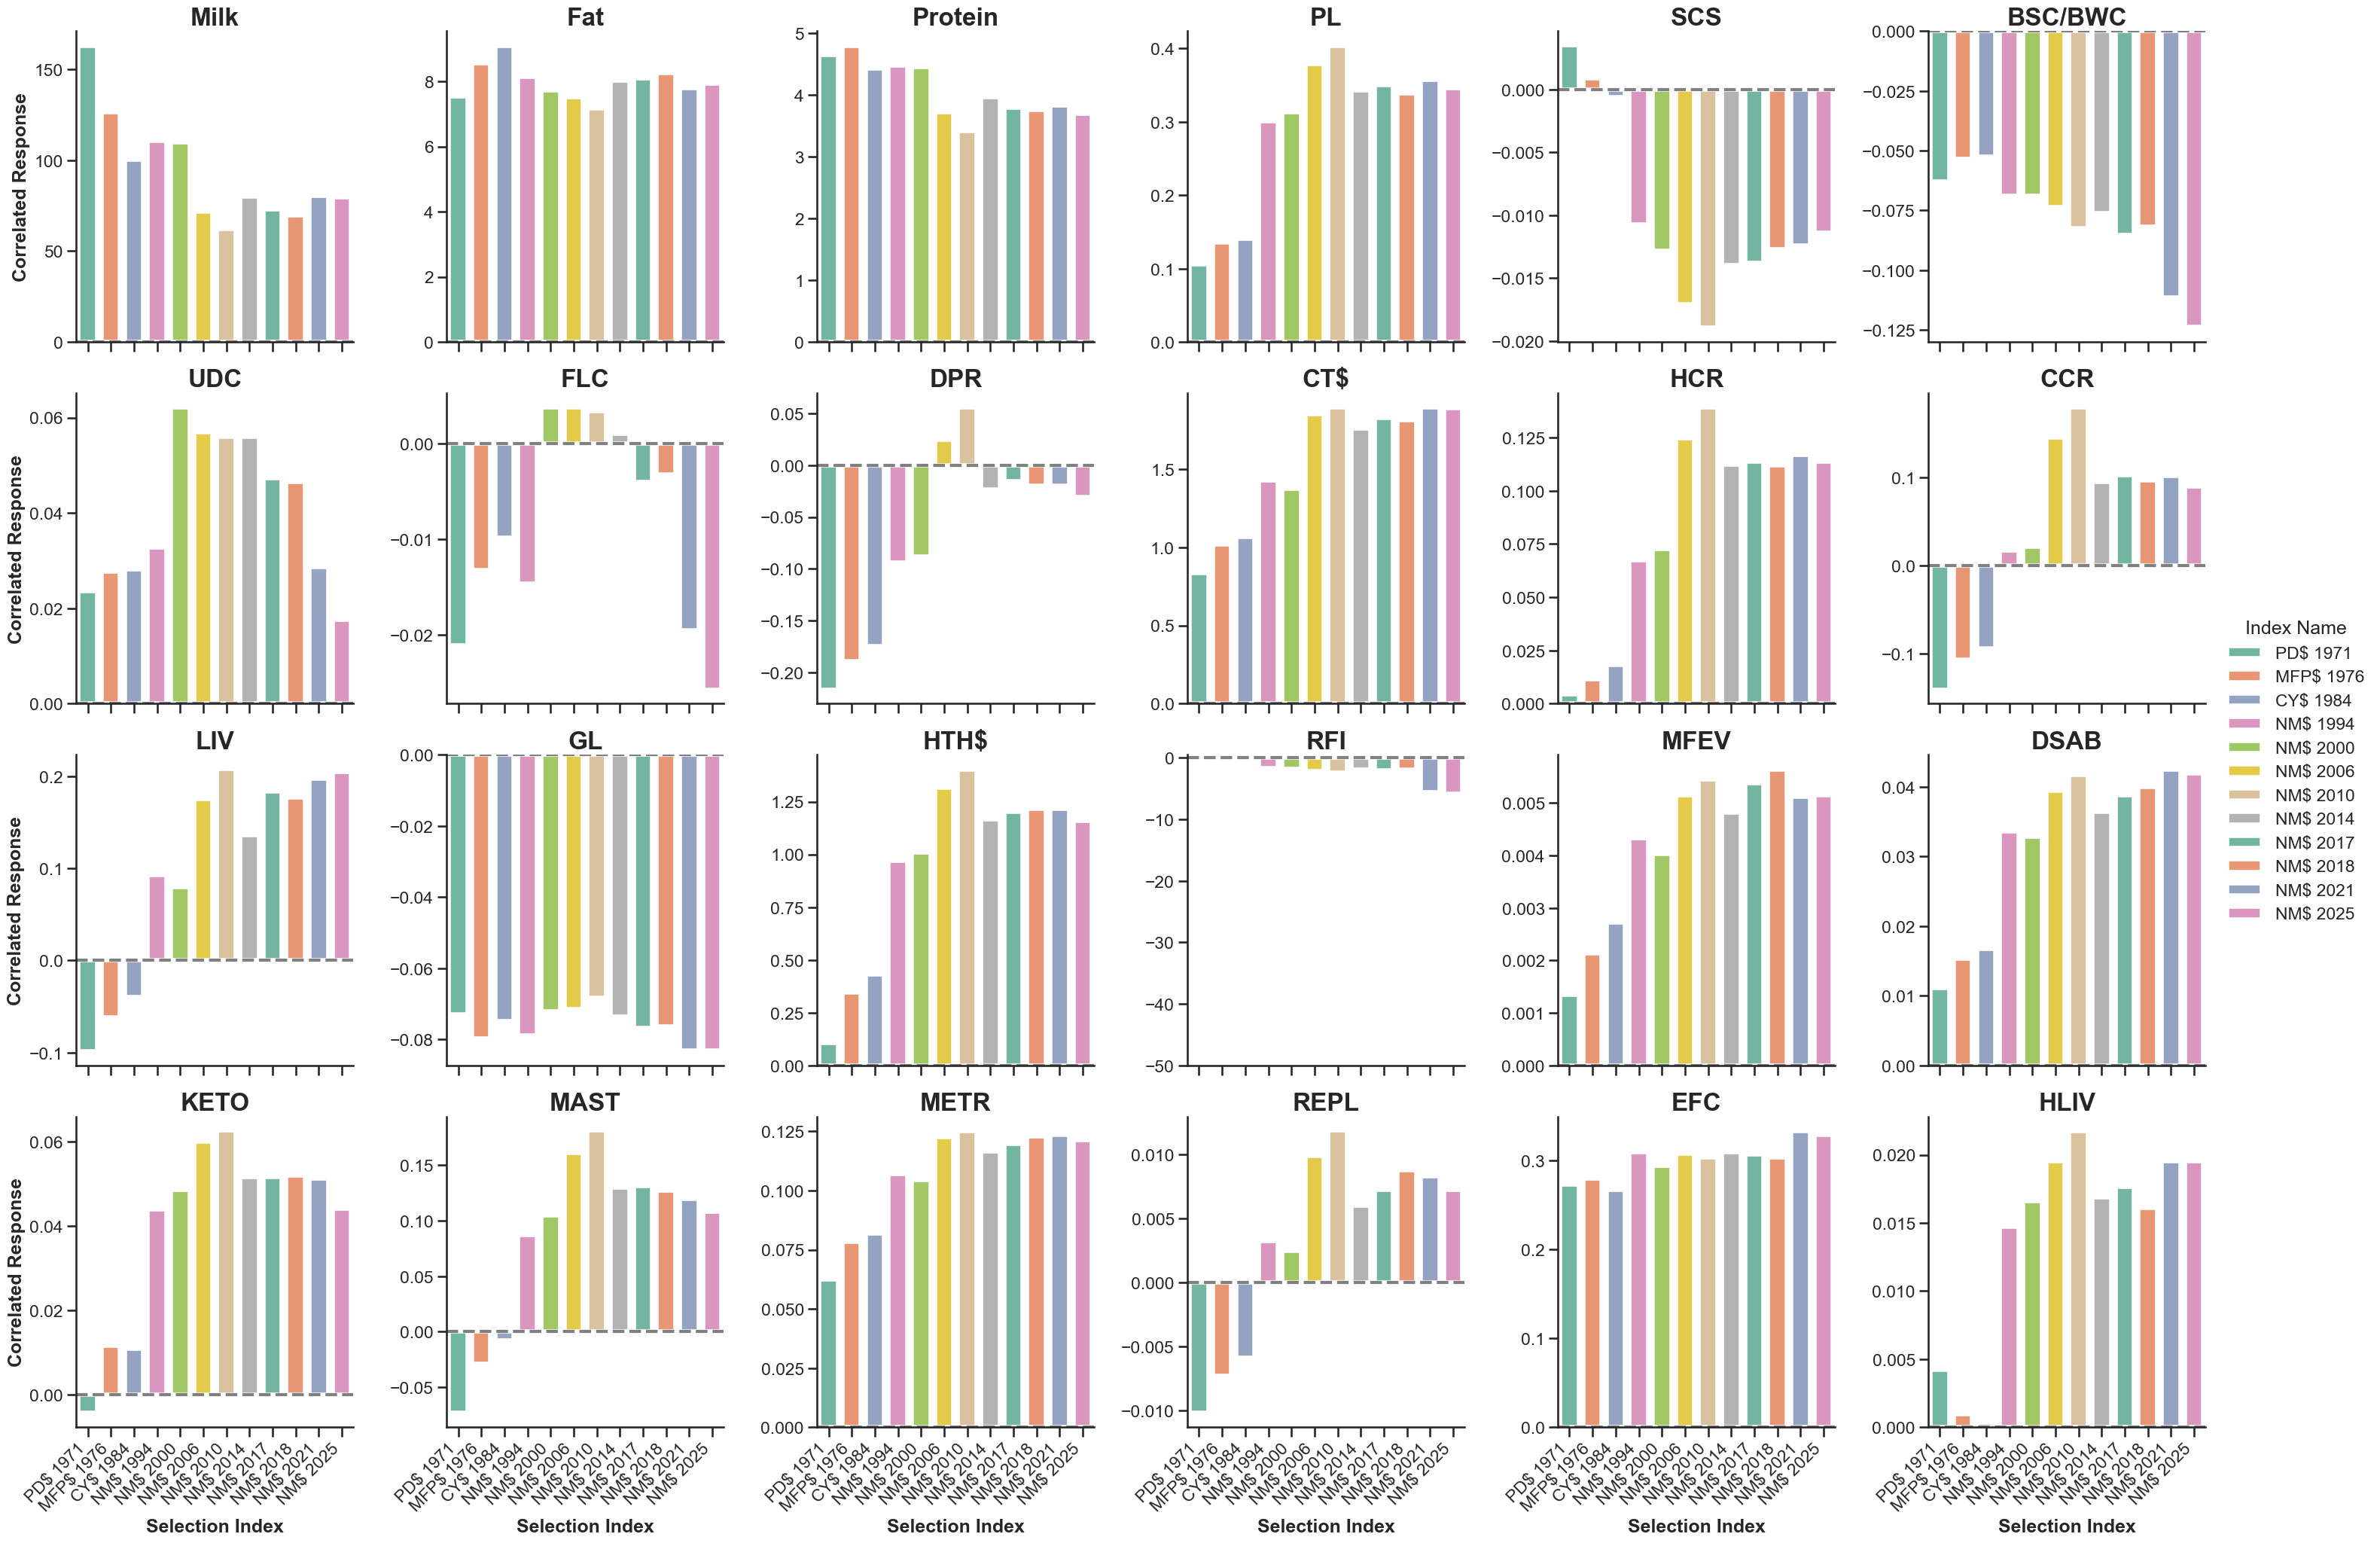

In [214]:
sns.set_style("white")
sns.set_style("ticks")
sns.set_context("talk")
r = sns.catplot(
    data=tall_response,
    x="Year",
    y="value",
    col="variable",
    hue="Index Name",
    kind="bar",
    col_wrap=6,
    native_scale=True,
    sharey=False,
    palette="Set2",
    col_order= [ 'Milk', 'Fat', 'Protein', 'PL', 'SCS', 'BSC/BWC', 'UDC', 'FLC', 'DPR', 'CT$',
                 'HCR', 'CCR', 'LIV', 'GL', 'HTH$', 'RFI', 'MFEV', 'DSAB', 'KETO', 'MAST',
                 'METR', 'REPL', 'EFC', 'HLIV'],
    **{"linewidth": 4,},
)
# Make all figures share a common y-axis minimum.
#r.set(ylim=(-1, None))
sns.set(font_scale = 2)

# I want to set all y-axes to a minimum of 0, except for RFI
axes = r.axes
axes[15].set_ylim(-50,)
for ax in axes:
    ax.axhline(0, ls='--', linewidth=3, color='gray')

# Label the axes
r.set_axis_labels("Selection Index", "Correlated Response", fontdict= {'fontweight':'bold'})
# Put the trait name as a title on each subplot.
r.set_titles("{col_name}", fontdict= {'fontweight':'bold'})
r.set_xticklabels(tall_response['Index Name'].unique(), rotation=45, ha="right")
#r.despine()
r.savefig('Cole 2025 Figure 2.png', dpi=600, transparent=True, bbox_inches='tight')